---
title: "Question3: [Fine-Tuning] Gemma-3-1b-it for Classification in Healthcare"
author: ["Guntas Singh Saran", "Prathmesh Maharshi"]
date: "2025-04-10"
image: "output.png"
format:
    html:
        code-fold: false
        code-tools: true
jupyter: python3
---

In [ ]:
!pip install -U transformers bitsandbytes accelerate peft datasets wandb

In [2]:
from transformers import pipeline, AutoModelForCausalLM, AutoTokenizer, Trainer, TrainingArguments, DataCollatorForLanguageModeling, BitsAndBytesConfig
import torch
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, accuracy_score
import pandas as pd
from peft import LoraConfig, get_peft_model
import bitsandbytes
from datasets import load_dataset
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

torch.cuda.set_device(0)
device = torch.device("cuda:0")

In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [ ]:
import wandb
wandb.login(key="<KEY>")

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: guntas-13 (guntas-13-indian-institute-of-technology-gandhinagar) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [5]:
wandb.init(project = "AISG_LLMFineTune", name = "Gemmav2.0")

In [6]:
ds = load_dataset("hpe-ai/medical-cases-classification-tutorial")
ds

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/192 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


medical_cases_train.csv:   0%|          | 0.00/6.34M [00:00<?, ?B/s]

medical_cases_validation.csv:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

medical_cases_test.csv:   0%|          | 0.00/1.32M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1724 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/370 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/370 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['description', 'transcription', 'sample_name', 'medical_specialty', 'keywords'],
        num_rows: 1724
    })
    validation: Dataset({
        features: ['description', 'transcription', 'sample_name', 'medical_specialty', 'keywords'],
        num_rows: 370
    })
    test: Dataset({
        features: ['description', 'transcription', 'sample_name', 'medical_specialty', 'keywords'],
        num_rows: 370
    })
})

In [7]:
df = pd.DataFrame(ds["train"])
df

,description,transcription,sample_name,medical_specialty,keywords
0,Pacemaker ICD interrogation. Severe nonischem...,"PROCEDURE NOTE: , Pacemaker ICD interrogation....",Pacemaker Interrogation,Cardiovascular / Pulmonary,"cardiovascular / pulmonary, cardiomyopathy, ve..."
1,"Erythema of the right knee and leg, possible s...","PREOPERATIVE DIAGNOSES: , Erythema of the righ...",Aspiration - Knee Joint,Orthopedic,"orthopedic, knee and leg, anterolateral portal..."
2,Left cardiac catheterization with selective ri...,"PREOPERATIVE DIAGNOSIS: , Post infarct angina....",Cardiac Cath & Selective Coronary Angiography,Cardiovascular / Pulmonary,"cardiovascular / pulmonary, selective, angiogr..."
3,Patient with a history of coronary artery dise...,"REASON FOR VISIT: , Acute kidney failure.,HIST...",Acute Kidney Failure,Nephrology,None
4,Cardiac evaluation and treatment in a patient ...,"REASON FOR REFERRAL: , Cardiac evaluation and ...",Cardiac Consultation - 6,Cardiovascular / Pulmonary,None
...,...,...,...,...,...
1719,"Arthroscopy of the left knee, left arthroscopi...","PREOPERATIVE DIAGNOSIS:, Medial meniscal tear...","Arthroscopy, Meniscoplasty, & Chondroplasty",Orthopedic,"orthopedic, medial meniscoplasty, arthroscopic..."
1720,Normal awake and drowsy (stage I sleep) EEG fo...,"DESCRIPTION OF RECORD: ,This tracing was obta...",Electroencephalogram,Neurology,"neurology, gold-plated surface disc electrodes..."
1721,MRI of the brain without contrast to evaluate ...,"EXAM: , MRI of the brain without contrast.,HIS...",MRI of Brain w/o Contrast.,Neurology,"neurology, mri, diffusion, posterior fossa, ax..."
1722,The patient comes for three-week postpartum ch...,"CHIEF COMPLAINT:, The patient comes for three...",Three-Week Postpartum Checkup,Obstetrics / Gynecology,"obstetrics / gynecology, checkup, allergies, p..."


### Train set metrics

In [8]:
df["medical_specialty"].value_counts()

,count
medical_specialty,
Cardiovascular / Pulmonary,526
Orthopedic,289
Neurology,187
Gastroenterology,152
Obstetrics / Gynecology,126
Hematology - Oncology,86
Neurosurgery,76
ENT - Otolaryngology,53
Pediatrics - Neonatal,51


### Test set metrics

In [9]:
df1 = pd.DataFrame(ds["test"])
df1["medical_specialty"].value_counts()

,count
medical_specialty,
Cardiovascular / Pulmonary,109
Orthopedic,57
Neurology,47
Gastroenterology,41
Obstetrics / Gynecology,32
Neurosurgery,20
Hematology - Oncology,15
ENT - Otolaryngology,14
Ophthalmology,11


In [10]:
classes = list(df["medical_specialty"].unique())
classes

['Cardiovascular / Pulmonary',
 'Orthopedic',
 'Nephrology',
 'Obstetrics / Gynecology',
 'Ophthalmology',
 'Gastroenterology',
 'Neurology',
 'ENT - Otolaryngology',
 'Psychiatry / Psychology',
 'Pediatrics - Neonatal',
 'Neurosurgery',
 'Hematology - Oncology',
 'Radiology']

In [11]:
cls_str = ", ".join(classes)
cls_str

'Cardiovascular / Pulmonary, Orthopedic, Nephrology, Obstetrics / Gynecology, Ophthalmology, Gastroenterology, Neurology, ENT - Otolaryngology, Psychiatry / Psychology, Pediatrics - Neonatal, Neurosurgery, Hematology - Oncology, Radiology'

# Load model

In [ ]:
!huggingface-cli login --token <TOKEN>

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: fineGrained).
The token `llm` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
The current active token is: `llm`


## Quantize the model

In [13]:
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

# quantize

In [14]:
model_name = "google/gemma-3-1b-it"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, quantization_config=quant_config)
model.to(device)

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

Gemma3ForCausalLM(
  (model): Gemma3TextModel(
    (embed_tokens): Gemma3TextScaledWordEmbedding(262144, 1152, padding_idx=0)
    (layers): ModuleList(
      (0-25): 26 x Gemma3DecoderLayer(
        (self_attn): Gemma3Attention(
          (q_proj): Linear4bit(in_features=1152, out_features=1024, bias=False)
          (k_proj): Linear4bit(in_features=1152, out_features=256, bias=False)
          (v_proj): Linear4bit(in_features=1152, out_features=256, bias=False)
          (o_proj): Linear4bit(in_features=1024, out_features=1152, bias=False)
          (q_norm): Gemma3RMSNorm((256,), eps=1e-06)
          (k_norm): Gemma3RMSNorm((256,), eps=1e-06)
        )
        (mlp): Gemma3MLP(
          (gate_proj): Linear4bit(in_features=1152, out_features=6912, bias=False)
          (up_proj): Linear4bit(in_features=1152, out_features=6912, bias=False)
          (down_proj): Linear4bit(in_features=6912, out_features=1152, bias=False)
          (act_fn): PytorchGELUTanh()
        )
        (input_l

In [15]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 1,490,944 || all params: 1,001,376,896 || trainable%: 0.1489


In [16]:
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    model.config.pad_token_id = model.config.eos_token_id

# Preprocess the data for fine-tuning

In [17]:
prompt_template = """
Classify this medical description into one of these specialties: {cls_str}
Description: {description}
Specialty:
"""

In [18]:
def preprocess_data(examples):
    prompts = []
    labels = []
    for desc, specialty in zip(examples["description"], examples["medical_specialty"]):
        prompt = prompt_template.format(cls_str=cls_str, description=desc)
        label = f"[{specialty.strip()}]"  # Ground truth in [Specialty] format
        prompts.append(prompt)
        labels.append(label)
    return {"prompt": prompts, "label": labels}

# we will use 50% of `train` data around `860` examples and `test` as the testing!

In [19]:
dataset = load_dataset("hpe-ai/medical-cases-classification-tutorial", split="train")
dataset = dataset.train_test_split(test_size=0.5)
train_data = dataset["train"]
test_data = ds["test"]
print("Length of Training Dataset:", len(train_data))
train_dataset = train_data.map(preprocess_data, batched=True)
test_dataset = test_data.map(preprocess_data, batched=True)

Repo card metadata block was not found. Setting CardData to empty.


Length of Training Dataset: 862


Map:   0%|          | 0/862 [00:00<?, ? examples/s]

Map:   0%|          | 0/370 [00:00<?, ? examples/s]

In [20]:
def format_for_training(examples):
    texts = [p + l for p, l in zip(examples["prompt"], examples["label"])]
    return {"text": texts}

In [21]:
train_dataset = train_dataset.map(format_for_training, batched=True)
test_dataset = test_dataset.map(format_for_training, batched=True)

Map:   0%|          | 0/862 [00:00<?, ? examples/s]

Map:   0%|          | 0/370 [00:00<?, ? examples/s]

# Tokenize the training and testing data

In [22]:
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=512)

In [23]:
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/862 [00:00<?, ? examples/s]

Map:   0%|          | 0/370 [00:00<?, ? examples/s]

In [24]:
# Remove unnecessary columns
tokenized_train = tokenized_train.remove_columns(["description", "medical_specialty", 'transcription', 'sample_name', 'keywords', "prompt", "label", "text"])
tokenized_test = tokenized_test.remove_columns(["description", "medical_specialty", 'transcription', 'sample_name', 'keywords', "prompt", "label", "text"])

In [25]:
tokenized_train

Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 862
})

In [26]:
tokenized_train.features['input_ids']

Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None)

# Fine Tuning Start

In [27]:
training_args = TrainingArguments(
    output_dir="./gemma-3-1b-it",
    per_device_train_batch_size=4,
    num_train_epochs=3,
    learning_rate=2e-4,
    weight_decay=0.01,
    save_strategy="epoch",
    # save_steps=100,
    # per_device_eval_batch_size=4,
    # eval_strategy="epoch",
    # load_best_model_at_end=True,
    logging_dir="./logs",
    logging_steps=10,
    fp16=True
)

In [28]:
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    data_collator=data_collator,
)

trainer.train()

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
It is strongly recommended to train Gemma3 models with the `eager` attention implementation instead of `sdpa`. Use `eager` with `AutoModelForCausalLM.from_pretrained('<path-to-checkpoint>', attn_implementation='eager')`.


Step,Training Loss
10,3.693000
20,2.246200
30,1.586700
40,1.216600
50,1.071000
60,1.138600
70,1.044800
80,1.010100
90,1.058300
100,0.982900


TrainOutput(global_step=648, training_loss=0.9956869976020154, metrics={'train_runtime': 741.942, 'train_samples_per_second': 3.485, 'train_steps_per_second': 0.873, 'total_flos': 5556064673857536.0, 'train_loss': 0.9956869976020154, 'epoch': 3.0})

In [ ]:
model_path = "./gemma-3-1b-it/pytorch_model.bin"
torch.save(model.state_dict(), model_path)

artifact = wandb.Artifact(name="gemma-3-1b-it-v2", type="model")
artifact.add_file(local_path=model_path, name="pytorch_model.bin")
wandb.log_artifact(artifact)

# Evaluation

In [ ]:
!pip install rapidfuzz

In [31]:
import re
from rapidfuzz import fuzz, process

dataset = test_dataset

predictions = []
true_labels = []

model.eval()
for i in range(0, len(dataset["prompt"]), 4):
    batch_prompts = dataset["prompt"][i:i+4]
    inputs = tokenizer(batch_prompts, return_tensors="pt", padding="max_length", truncation=True, max_length=512).to(device)

    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=20)

    decoded_outputs = tokenizer.batch_decode(outputs, skip_special_tokens=True)
    batch_preds = []
    for prompt, output in zip(batch_prompts, decoded_outputs):
        generated_text = output[len(prompt):].strip()

        pattern = '|'.join(map(re.escape, classes))
        match = re.search(pattern, generated_text)

        if match:
            pred = match.group(0)
        else:
          if "Cardiology" in generated_text:
            pred = "Cardiovascular / Pulmonary"
            print(f"Found 'Cardiology' in '{generated_text}', mapping to '{pred}'")
          else:
            best_match = process.extractOne(generated_text, classes, scorer=fuzz.partial_ratio)
            pred = best_match[0]
            score = best_match[1]
            print(f"No exact match in '{generated_text}', nearest match: '{pred}' (score: {score})")

        batch_preds.append(pred)

    predictions.extend(batch_preds)
    true_labels.extend([label.strip("[]") for label in dataset["label"][i:i + 4]])

No exact match in '[Otolaryngology]
Specialty:
[Otology]
Classify this medical', nearest match: 'ENT - Otolaryngology' (score: 80.0)
No exact match in '[Otolaryngology]
Specialty: [Otolaryngology]
Classify this', nearest match: 'ENT - Otolaryngology' (score: 80.0)


In [33]:
pred_df = pd.DataFrame({"prompt": dataset["prompt"][:len(predictions)], "prediction": predictions, "true_label": true_labels})
pred_file = "./predictions.csv"
pred_df.to_csv(pred_file, index=False)

pred_artifact = wandb.Artifact(name="gemma-3-1b-it-v2-predictions", type="predictions")
pred_artifact.add_file(local_path=pred_file, name="predictions.csv")
wandb.log_artifact(pred_artifact)

accuracy = accuracy_score(true_labels, predictions)
precision, recall, f1, _ = precision_recall_fscore_support(true_labels, predictions, average="weighted", zero_division=0)
conf_matrix = confusion_matrix(true_labels, predictions, labels=classes)

In [34]:
torch.cuda.synchronize()

Accuracy: 0.686
Precision: 0.707
Recall: 0.686
F1 Score: 0.692
Confusion Matrix:
[[95  1  2  0  0  1  3  0  0  2  0  2  3]
 [ 0 43  0  0  0  0  6  0  0  0  8  0  0]
 [ 1  0  6  0  0  1  0  0  1  0  0  0  1]
 [ 1  0  0 27  0  0  0  0  0  1  0  1  2]
 [ 0  0  0  0  9  0  2  0  0  0  0  0  0]
 [ 6  0  3  3  0 26  0  0  0  0  0  2  1]
 [ 7 10  1  0  0  0 21  0  0  0  6  2  0]
 [ 0  0  0  0  0  0  3 10  0  0  1  0  0]
 [ 0  0  0  0  0  0  2  0  7  0  0  0  0]
 [ 2  0  0  0  0  0  1  0  0  0  0  0  0]
 [ 2  8  1  0  0  0  4  0  0  0  4  1  0]
 [ 1  0  0  5  1  0  0  0  0  0  0  6  2]
 [ 1  0  0  0  0  0  1  0  0  0  0  0  0]]


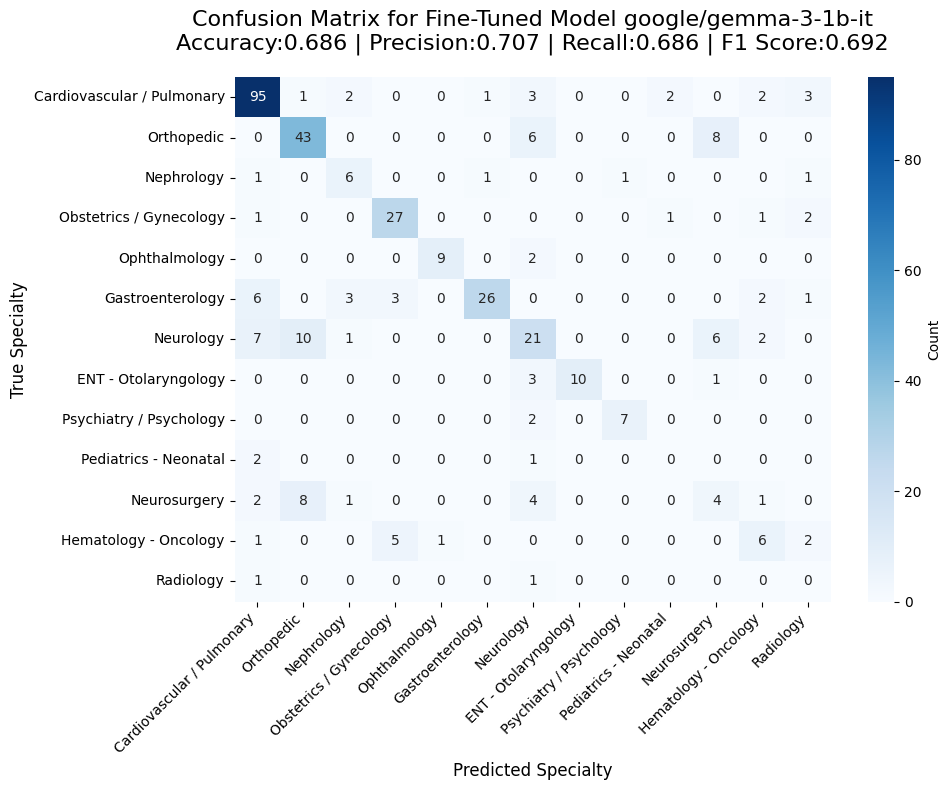

In [35]:
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")
print("Confusion Matrix:")
print(conf_matrix)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes,
            cbar_kws={'label': 'Count'})
plt.title(f"Confusion Matrix for Fine-Tuned Model {model_name}\nAccuracy:{accuracy:.3f} | Precision:{precision:.3f} | Recall:{recall:.3f} | F1 Score:{f1:.3f}", fontsize=16, pad=20)
plt.xlabel("Predicted Specialty", fontsize=12)
plt.ylabel("True Specialty", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [36]:
row_sums = np.sum(conf_matrix, axis=1)
row_sums

array([109,  57,  10,  32,  11,  41,  47,  14,   9,   3,  20,  15,   2])

In [37]:
row_sums.sum()

np.int64(370)

In [38]:
wandb.log({"accuracy": accuracy, "precision": precision, "recall": recall, "f1_score": f1})
wandb.finish()

accuracy,▁
f1_score,▁
precision,▁
recall,▁
train/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇██
train/global_step,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
train/grad_norm,█▇▆▄▂▃▂▁▂▁▂▂▃▂▂▂▂▂▃▂▄▂▂▂▄▃▁▂▃▃▃▂▄▂▃▃▃▃▃▄
train/learning_rate,█████▇▇▇▇▇▆▆▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▄▃▃▃▂▂▂▂▁▁▁▁
train/loss,█▅▃▂▂▂▂▂▂▁▂▁▂▂▂▁▁▁▁▁▁▁▁▂▁▂▁▁▁▁▁▁▁▁▁▂▁▁▂▁
accuracy,0.68649
f1_score,0.69161
